In [4]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit

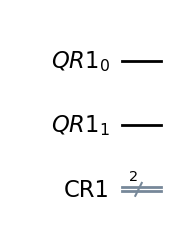

In [9]:
qr1 = QuantumRegister(2, 'QR1')
cr1 = ClassicalRegister(2, 'CR1')
qc1 = QuantumCircuit(qr1, cr1)
qc1.draw(output='mpl')

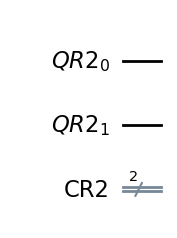

In [12]:
qr2 = QuantumRegister(2, 'QR2')
cr2 = ClassicalRegister(2, 'CR2')
qc2 = QuantumCircuit(qr2, cr2)
qc2.draw(output='mpl')

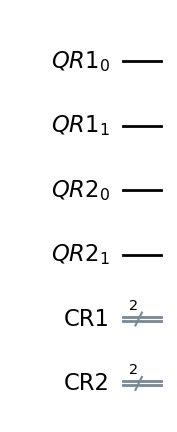

In [14]:
qc_combined = QuantumCircuit()
qc_combined.add_register(qr1, qr2, cr1, cr2)
qc_combined.draw(output='mpl')

In [15]:
from qiskit.circuit.random import random_circuit

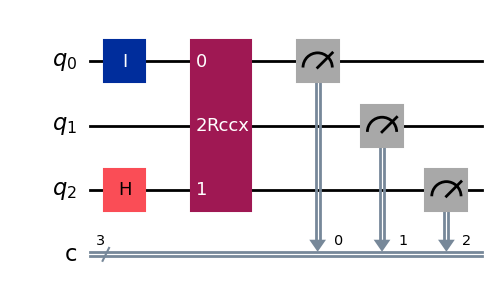

In [16]:
qc = random_circuit(3,2, measure=True)
qc.draw(output='mpl')

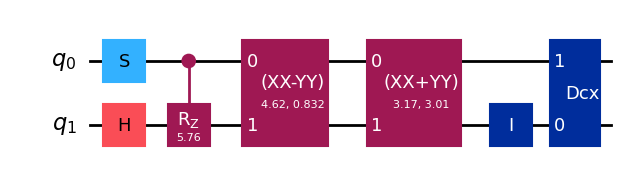

In [29]:
qc1 = random_circuit(2,2)
qc2 = random_circuit(2,4)
qc = qc1.compose(qc2, [0,1])
qc.draw(output='mpl')

In [23]:
def print_circuit_props(qc):
    width = qc.width()
    depth = qc.depth()
    num_operators = qc.count_ops()
    circuit_size = qc.size()
    print(f'Width = {width}')
    print(f'Depth = {depth}')
    print(f'Circuit size = {circuit_size}')
    print(f'Number of operators = {num_operators}')

In [32]:
print_circuit_props(qc)

Width = 4
Depth = 7
Circuit size = 9
Number of operators = OrderedDict({'measure': 2, 's': 1, 'h': 1, 'crz': 1, 'xx_minus_yy': 1, 'xx_plus_yy': 1, 'id': 1, 'dcx': 1, 'barrier': 1})


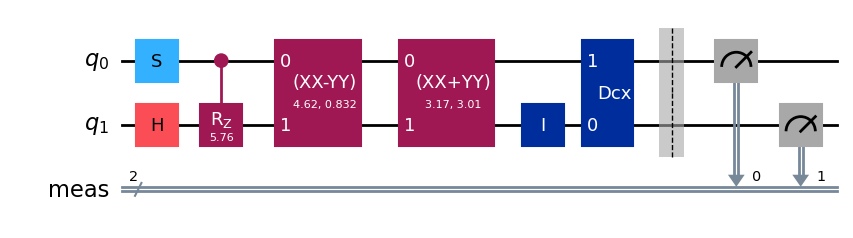

In [31]:
qc.measure_all()
qc.draw(output='mpl')

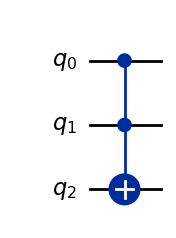

In [33]:
qc = QuantumCircuit(3)
qc.ccx(0,1,2)
qc.draw(output='mpl')

In [34]:
print_circuit_props(qc)

Width = 3
Depth = 1
Circuit size = 1
Number of operators = OrderedDict({'ccx': 1})


In [35]:
print_circuit_props(qc.decompose())

Width = 3
Depth = 11
Circuit size = 15
Number of operators = OrderedDict({'cx': 6, 't': 4, 'tdg': 3, 'h': 2})


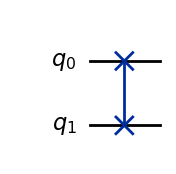

In [38]:
qc = QuantumCircuit(2)
qc.swap(0,1)
qc.draw(output='mpl')

In [39]:
print_circuit_props(qc)

Width = 2
Depth = 1
Circuit size = 1
Number of operators = OrderedDict({'swap': 1})


In [40]:
print_circuit_props(qc.decompose())

Width = 2
Depth = 3
Circuit size = 3
Number of operators = OrderedDict({'cx': 3})


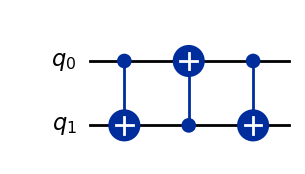

In [41]:
qc.decompose().draw(output='mpl')

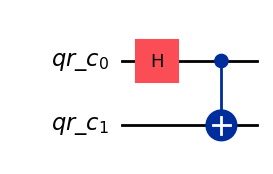

In [43]:
qr = QuantumRegister(2, name='qr_c')
comp_qc = QuantumCircuit(qr, name='My-composite')
comp_qc.h(0)
comp_qc.cx(0,1)
composite_inst = comp_qc.to_instruction()
comp_qc.draw(output='mpl')

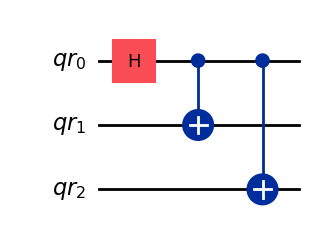

In [44]:
qr2 = QuantumRegister(3, 'qr')
qc = QuantumCircuit(qr2)
qc.h(0)
qc.cx(0,1)
qc.cx(0,2)
qc.draw(output='mpl')

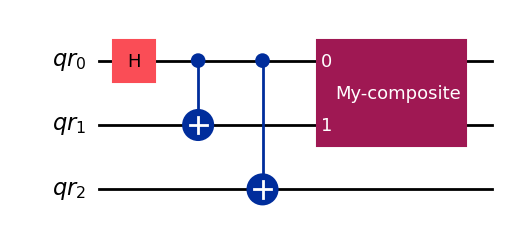

In [46]:
qc.append(composite_inst, [qr2[0], qr2[1]])
qc.draw(output='mpl')

In [48]:
from qiskit.circuit import Parameter

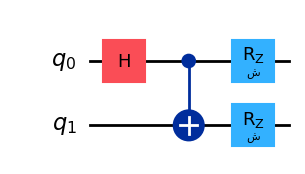

In [50]:
param_theta = Parameter('ش')
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0,1)
qc.rz(param_theta, 0)
qc.rz(param_theta, 1)
qc.draw(output='mpl')

In [51]:
import numpy as np

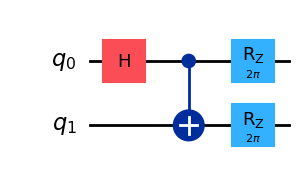

In [52]:
qc = qc.assign_parameters(parameters={param_theta: 2*np.pi})
qc.draw(output='mpl')

In [62]:
from qiskit_ibm_runtime import QiskitRuntimeService, Session, SamplerV2 as Sampler

In [65]:
service = QiskitRuntimeService()
print(f"Backends: {service.backends()}")

Backends: [<IBMBackend('ibm_fez')>, <IBMBackend('ibm_torino')>, <IBMBackend('ibm_marrakesh')>]


/Users/demouser/.local/share/virtualenvs/qiskit-playground-xSEsUWdl/lib/python3.14/site-packages/qiskit/visualization/circuit/matplotlib.py:272: UserWarning: Style JSON file 'default.json' not found in any of these locations: /Users/demouser/.local/share/virtualenvs/qiskit-playground-xSEsUWdl/lib/python3.14/site-packages/qiskit/visualization/circuit/styles/default.json, ~/default.json, ~/.qiskit/default.json, default.json. Will use default style.
  self._style, def_font_ratio = load_style(


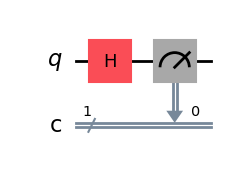

In [66]:
backend = service.backend("ibm_fez")
qc = QuantumCircuit(1,1)
qc.h(0)
qc.measure([0], [0])
qc.draw(output='mpl')

In [90]:
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

pm = generate_preset_pass_manager(backend=backend)
sampler = Sampler(mode=backend)
transpiled = pm.run(qc)
job = sampler.run([transpiled], shots=128)
print(f"Job ID: {job.job_id()}")
print(f"Job Status: {job.status()}")
result = job.result()
print(f"Job Result: {result}")
for r in result:
    plot_histogram(r.data.values)

Job ID: d6nofru9td6c73aof3ng
Job Status: QUEUED
Job Result: PrimitiveResult([SamplerPubResult(data=DataBin(c=BitArray(<shape=(), num_shots=128, num_bits=1>)), metadata={'circuit_metadata': {}})], metadata={'execution': {'execution_spans': ExecutionSpans([DoubleSliceSpan(<start='2026-03-10 02:54:55', stop='2026-03-10 02:54:56', size=128>)])}, 'version': 2})


AttributeError: 'function' object has no attribute 'values'

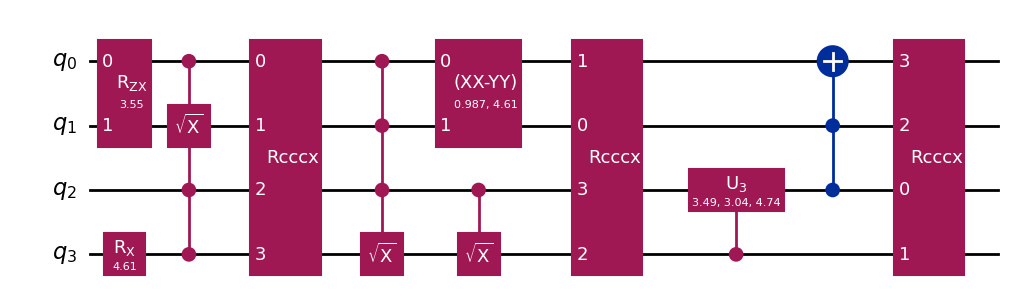

In [79]:
qca = random_circuit(4,9)
qca.draw(output='mpl')

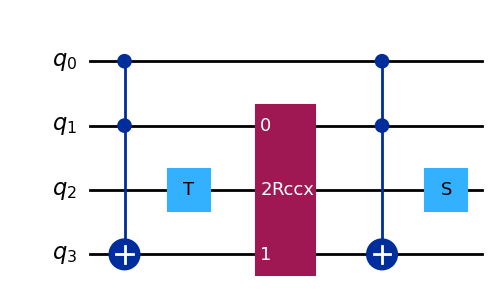

In [80]:

qcb = random_circuit(4,3)
qcb.draw(output='mpl')

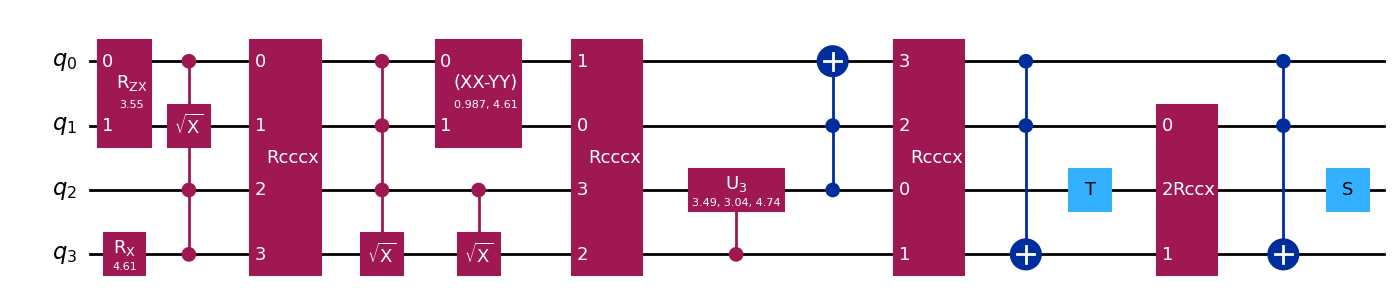

In [82]:
qcc = qca.compose(qcb, [0,1,2,3])
qcc.draw(output='mpl')

In [84]:
print_circuit_props(qcc)

Width = 4
Depth = 12
Circuit size = 16
Number of operators = OrderedDict({'rcccx': 3, 'ccx': 3, 'c3sx': 2, 'rzx': 1, 'rx': 1, 'csx': 1, 'xx_minus_yy': 1, 'cu3': 1, 't': 1, 'rccx': 1, 's': 1})


In [85]:
print_circuit_props(qcc.decompose())

Width = 4
Depth = 137
Circuit size = 193
Number of operators = OrderedDict({'cx': 57, 'h': 52, 't': 26, 'tdg': 23, 'cp': 14, 'p': 4, 'rz': 3, 'sdg': 3, 's': 3, 'ry': 2, 'u': 2, 'r': 1, 'sx': 1, 'sxdg': 1, 'cs': 1})


/Users/demouser/.local/share/virtualenvs/qiskit-playground-xSEsUWdl/lib/python3.14/site-packages/qiskit/visualization/circuit/matplotlib.py:272: UserWarning: Style JSON file 'default.json' not found in any of these locations: /Users/demouser/.local/share/virtualenvs/qiskit-playground-xSEsUWdl/lib/python3.14/site-packages/qiskit/visualization/circuit/styles/default.json, ~/default.json, ~/.qiskit/default.json, default.json. Will use default style.
  self._style, def_font_ratio = load_style(


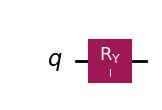

In [87]:
param_alif = Parameter('ا')
qcd = QuantumCircuit(1)
qcd.ry(param_alif, 0)
qcd.draw(output='mpl')

/Users/demouser/.local/share/virtualenvs/qiskit-playground-xSEsUWdl/lib/python3.14/site-packages/qiskit/visualization/circuit/matplotlib.py:272: UserWarning: Style JSON file 'default.json' not found in any of these locations: /Users/demouser/.local/share/virtualenvs/qiskit-playground-xSEsUWdl/lib/python3.14/site-packages/qiskit/visualization/circuit/styles/default.json, ~/default.json, ~/.qiskit/default.json, default.json. Will use default style.
  self._style, def_font_ratio = load_style(


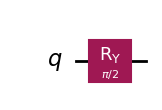

In [88]:
qce = qcd.assign_parameters(parameters={param_alif: np.pi / 2})
qce.draw(output='mpl')